## Malaria Cell Object Detection with PyTorch
This notebook demonstrates how to prepare the malaria cell dataset for object detection, set up a PyTorch Dataset and DataLoader, train a Faster R-CNN model, and visualize bounding boxes and predictions.

In [1]:
# Install required packages if not already installed
import sys
#!{sys.executable} -m pip install torch torchvision matplotlib pillow tqdm
import json
from pathlib import Path
import numpy as np
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import WeightedRandomSampler

### Check CUDA availability and PyTorch version

In [2]:
print(torchvision.__version__)
import torchvision.models.detection as detection
print([fn for fn in dir(detection) if fn.startswith("fasterrcnn")])
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

0.22.0+cu118
['fasterrcnn_mobilenet_v3_large_320_fpn', 'fasterrcnn_mobilenet_v3_large_fpn', 'fasterrcnn_resnet50_fpn', 'fasterrcnn_resnet50_fpn_v2']
PyTorch version: 2.7.0+cu118
CUDA available: True
Number of GPUs: 1
Current device: 0
Device name: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
from enum import Enum, auto

class RunMode(Enum):
    TRAIN = auto()
    BAYESIAN_OPTIMIZATION = auto()
    TEST = auto()

class LossFunction(Enum):
    WEIGHTED_CROSS_ENTROPY = auto()
    WEIGHTED_FOCAL = auto()

class ModelType(Enum):
    FASTERRCNN_RESNET50_FPN = auto()
    FASTERRCNN_RESNET50_FPN_V2 = auto()


run_mode = RunMode.TRAIN
loss_function = LossFunction.WEIGHTED_FOCAL
model_type = ModelType.FASTERRCNN_RESNET50_FPN_V2

model_folder = Path("faster_rcnn_resnet50_fpn_v2_weighted_focal_loss")
model_folder.mkdir(exist_ok=True)

num_epochs = 60

### Prepare PyTorch Dataset for Object Detection
Convert the JSON data into a PyTorch Dataset compatible with torchvision's Faster R-CNN.

In [4]:
CATEGORY_MAP = {
    'red blood cell': 1,
    'trophozoite': 2,
    'ring': 3,
    'difficult': 4,
    'schizont': 5,
    'gametocyte': 6,
    'leukocyte': 7
}

class MalariaCellDataset(Dataset):
    def __init__(self, data, images_dir, transforms=None):
        self.data = data
        self.images_dir = Path(images_dir)
        self.transforms = transforms

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img_path = self.images_dir / Path(item['image']['pathname']).name
        img = Image.open(img_path).convert('RGB')
        boxes = []
        labels = []
        for obj in item['objects']:
            bbox = obj['bounding_box']
            xmin = bbox['minimum']['c']
            ymin = bbox['minimum']['r']
            xmax = bbox['maximum']['c']
            ymax = bbox['maximum']['r']
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(CATEGORY_MAP[obj['category']])
        boxes_np = np.array(boxes, dtype=np.float32)
        labels_np = np.array(labels, dtype=np.int64)
        target = {
            'boxes': torch.as_tensor(boxes, dtype=torch.float32),
            'labels': torch.as_tensor(labels, dtype=torch.int64)
        }
        if self.transforms:
            transformed = self.transforms(
                image=np.array(img),
                bboxes=boxes_np,
                labels=labels_np
            )
            img = transformed['image']
            # Update target with transformed bboxes/labels
            target['boxes'] = torch.as_tensor(transformed['bboxes'], dtype=torch.float32)
            target['labels'] = torch.as_tensor(transformed['labels'], dtype=torch.int64)
        else:
            img = torchvision.transforms.functional.to_tensor(img)
        return img, target

### Malaria Data Loading and Visualization

In [5]:
class MalariaDataLoader:
    def __init__(self, images_dir="images"):
        self.images_dir = images_dir


    def load_dataset(self, json_file):
        with open(json_file, 'r') as f:
            data = json.load(f)
        return data


    @staticmethod
    def collate_fn(batch):
        return tuple(zip(*batch))


    def get_data_loader(self, json_file, batch_size=2, transforms=None):
        data = self.load_dataset(json_file)
        print(f'Total Images: {len(data)}')

        dataset = MalariaCellDataset(data, images_dir=self.images_dir, transforms=transforms)
        print(f'Dataset size: {len(dataset)}')
        img, target = dataset[0]

        if isinstance(img, torch.Tensor):
            print('Image shape:', img.shape)
        else:
            print('Image shape:', np.array(img).shape)

        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=self.collate_fn)
        batch = next(iter(dataloader))
        print('Batch loaded. Number of images:', len(batch[0]))

        return dataset, dataloader


    def get_class_distribution(self, dataset):
        """Count the number of instances for each class in the dataset."""
        # Count class frequencies
        class_counts = {k: 0 for k in CATEGORY_MAP if k != 'background'}
        for i in range(len(dataset)):
            _, target = dataset[i]
            labels = target['labels'].cpu().numpy()
            for label in labels:
                class_name = [k for k, v in CATEGORY_MAP.items() if v == label and k != 'background']
                if class_name:
                    class_counts[class_name[0]] += 1

        total = sum(class_counts.values())
        class_weights = [total / c if c > 0 else 0.0 for c in class_counts.values()]
        return class_counts, class_weights
    

    def get_oversampled_data_loader(self, json_file, batch_size=2, transforms=None):
        data = self.load_dataset(json_file)
        print(f'Total Images: {len(data)}')
        dataset = MalariaCellDataset(data, images_dir=self.images_dir, transforms=transforms)
        class_counts, class_weights = self.get_class_distribution(dataset)
        print('Class counts:', class_counts, 'Class weights:', class_weights)

        # Compute sample weights (inverse of class frequency for the first label in each sample)
        sample_weights = []
        for i in range(len(dataset)):
            _, target = dataset[i]
            labels = target['labels'].cpu().numpy()
            if len(labels) > 0:
                label = labels[0]
                class_name = [k for k, v in CATEGORY_MAP.items() if v == int(label) and k != 'background']
                if class_name and class_name[0] in class_counts:
                    weight = 1.0 / (class_counts[class_name[0]] + 1e-6)
                else:
                    weight = 1.0
            else:
                weight = 1.0
            sample_weights.append(weight)

        # Normalize weights so their sum equals the number of images
        sum_weights = sum(sample_weights)
        sample_weights = [w * len(sample_weights) / sum_weights for w in sample_weights]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(dataset), replacement=True)
        data_loader = DataLoader(dataset, batch_size=batch_size, sampler=sampler, collate_fn=self.collate_fn)
        return dataset, sampler, data_loader


class MalariaDataVisualizer:
    @staticmethod
    def plot_class_distribution(class_counts, type_of_data="Training"):
        """Plot the class distribution."""
        plt.figure(figsize=(10, 6))
        bars = plt.bar(class_counts.keys(), class_counts.values(), color='blue')
        for bar, count in zip(bars, class_counts.values()):
            plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom', fontsize=10)
        plt.xlabel('Class')
        plt.ylabel('Count')
        plt.title(f'Class Distribution in {type_of_data.capitalize()} Data')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


    @staticmethod
    def plot_oversampled_class_distribution(dataset, image_sampler):
        """Plot the class distribution after oversampling."""
        image_weights = list(image_sampler.weights)
        sampled_indices = list(image_sampler)[:10]
        sampled_filenames = [dataset.data[i]['image']['pathname'] for i in sampled_indices]
        print("Sampled image filenames:", sampled_filenames)
        print("\nSampled image indices:", sampled_indices)
        print("\nSampled image weights:", [image_weights[i] for i in sampled_indices])

        # Calculate total probability mass assigned to each class by summing image weights for images containing that class
        class_prob_mass = {k: 0.0 for k in CATEGORY_MAP if k != 'background'}
        for img_idx in range(len(dataset)):
            _, target = dataset[img_idx]
            labels = set(target['labels'].cpu().numpy())
            for label in labels:
                class_name = [k for k, v in CATEGORY_MAP.items() if v == label and k != 'background']
                if class_name:
                    class_prob_mass[class_name[0]] += image_weights[img_idx]

        # Normalize to get probability distribution
        total_mass = sum(class_prob_mass.values())
        class_probs = {k: (class_prob_mass[k] / total_mass if total_mass > 0 else 0) for k in class_prob_mass}

        # Plot
        plt.figure(figsize=(8, 4))
        plt.bar(
            list(class_probs.keys()),
            list(class_probs.values()),
            color='orange'
        )
        plt.ylabel('Probability Mass (Normalized)')
        plt.xlabel('Class')
        plt.title('Class Distribution Based on Oversampling Weights')
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

In [6]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

malaria_data_loader = MalariaDataLoader(images_dir="images")


# Define transformations for training dataset
train_transformations = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
    A.HueSaturationValue(p=0.3),
    A.Blur(blur_limit=3, p=0.2),
    A.GaussNoise(p=0.2),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

train_dataset, train_data_loader = malaria_data_loader.get_data_loader(json_file='training.json', batch_size=2, transforms=train_transformations)

train_oversampled_dataset, train_data_sampler, train_oversampled_data_loader = malaria_data_loader.get_oversampled_data_loader(json_file='training.json', batch_size=2, transforms=train_transformations)

Total Images: 1208
Dataset size: 1208
Image shape: torch.Size([3, 1200, 1600])
Batch loaded. Number of images: 2
Total Images: 1208
Class counts: {'red blood cell': 76847, 'trophozoite': 1472, 'ring': 353, 'difficult': 440, 'schizont': 179, 'gametocyte': 144, 'leukocyte': 103} Class weights: [1.0350176324384817, 54.03396739130435, 225.32011331444758, 180.76818181818183, 444.3463687150838, 552.3472222222222, 772.2135922330098]


In [7]:
# Define transformations for test dataset
test_transformations = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

test_dataset, test_data_loader = malaria_data_loader.get_data_loader(json_file='test.json', batch_size=2, transforms=test_transformations)

Total Images: 120
Dataset size: 120
Image shape: torch.Size([3, 1383, 1944])
Batch loaded. Number of images: 2


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\albumentations\core\composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


### Explore Class Distribution of Training Data

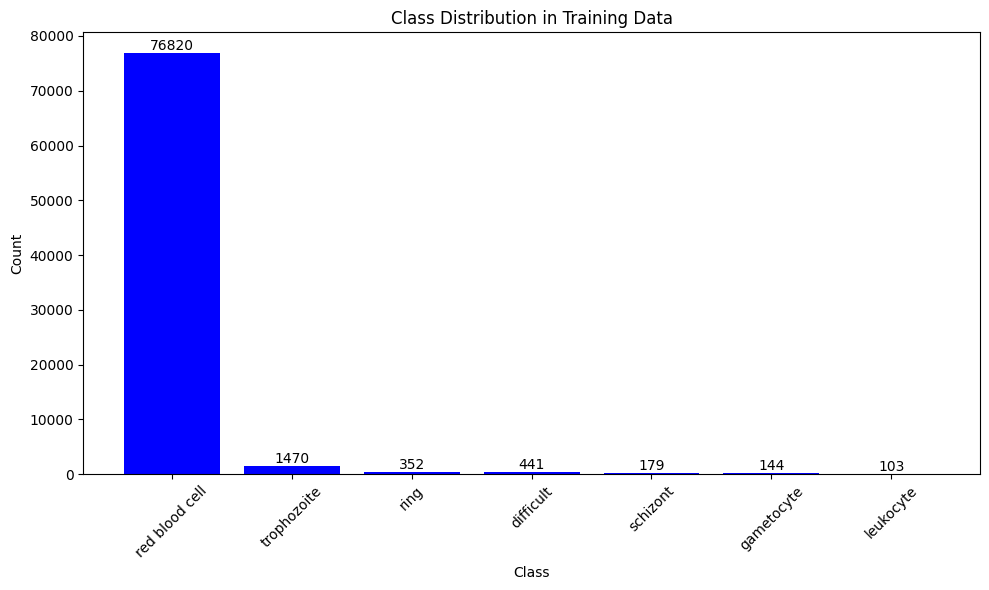

In [8]:
if run_mode == RunMode.TRAIN:
    # Plot training data class distribution
    training_data_class_distribution, _ = malaria_data_loader.get_class_distribution(train_dataset)
    MalariaDataVisualizer.plot_class_distribution(training_data_class_distribution, type_of_data="Training")

Sampled image filenames: ['/images/003a89b0-a095-417a-8dd6-f408339bbc68.png', '/images/1dd3e6dd-343f-4cc9-b0ed-e4d27fb36f0a.png', '/images/28c96a4a-4549-4761-99e4-ace4ea7e7ac9.png', '/images/8e4bdd0d-1c72-4836-ae3e-05e2e50e4983.png', '/images/2a6370b0-08f1-4c11-a639-265d4419c9a3.png', '/images/93f40356-5676-45d3-8e83-8028708c93ba.png', '/images/5a539312-6cfa-43e6-8d5d-db883f343ad9.png', '/images/28c96a4a-4549-4761-99e4-ace4ea7e7ac9.png', '/images/177f883a-f0f1-4b8e-b598-2ca4bab27381.png', '/images/93f40356-5676-45d3-8e83-8028708c93ba.png']

Sampled image indices: [588, 733, 764, 194, 513, 788, 679, 764, 368, 788]

Sampled image weights: [tensor(83.0367, dtype=torch.float64), tensor(83.0367, dtype=torch.float64), tensor(83.0367, dtype=torch.float64), tensor(0.1934, dtype=torch.float64), tensor(33.7808, dtype=torch.float64), tensor(103.2192, dtype=torch.float64), tensor(33.7808, dtype=torch.float64), tensor(83.0367, dtype=torch.float64), tensor(83.0367, dtype=torch.float64), tensor(103.2

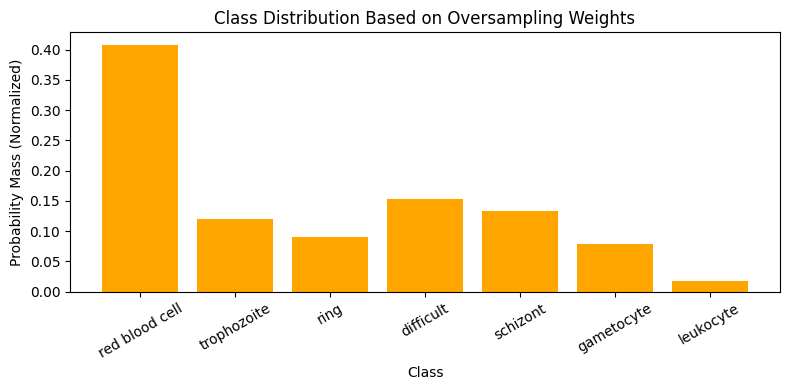

In [9]:
if run_mode == RunMode.TRAIN:
    # Plot oversampled training data class distribution
    MalariaDataVisualizer.plot_oversampled_class_distribution(train_oversampled_dataset, train_data_sampler)

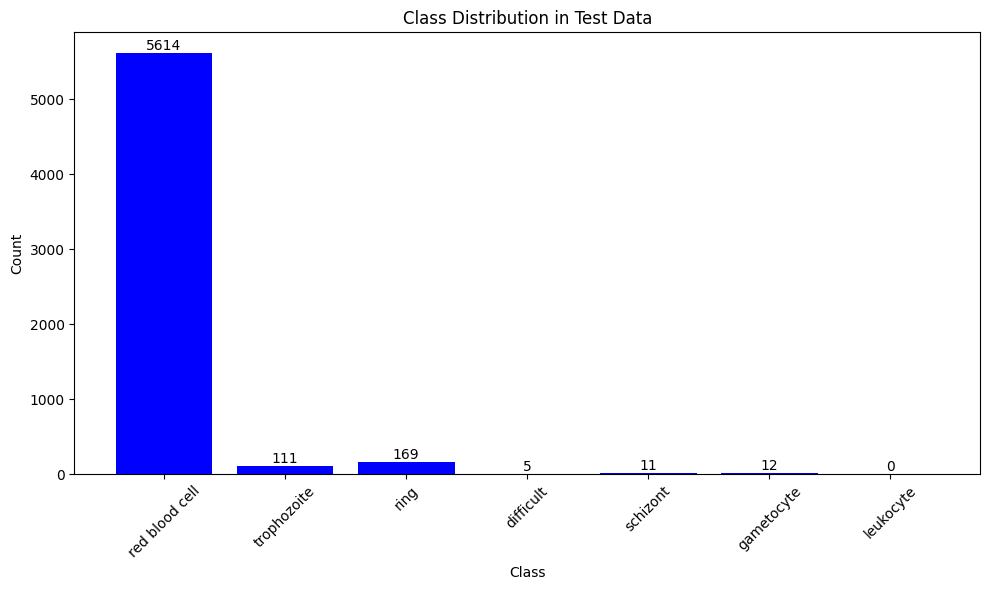

In [10]:
# Plot test data class distribution
test_data_class_distribution, _ = malaria_data_loader.get_class_distribution(test_dataset)
MalariaDataVisualizer.plot_class_distribution(test_data_class_distribution, type_of_data="Test")

### Fast R-CNN Weighted Predictor for Fast R-CNN Model

In [11]:
import torch.nn as nn
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights

import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean', class_weights=None):
        super().__init__()
        # Alpha should be a tensor if per-class, or a single float if balancing foreground/background
        self.alpha = alpha if alpha is not None else 0.25 # Default alpha
        self.gamma = gamma
        self.reduction = reduction
        self.class_weights = class_weights # These weights are applied inside F.cross_entropy

    def forward(self, inputs, targets):
        # inputs: raw logits [N, C]
        # targets: class indices [N]

        # Calculate CE loss without reduction
        ce_loss = F.cross_entropy(inputs, targets, weight=self.class_weights, reduction='none')

        # Get the probability of the true class
        pt = torch.exp(-ce_loss)

        # Calculate the focal term (1 - pt)^gamma
        focal_term = (1 - pt) ** self.gamma

        # Apply alpha weighting
        # alpha_t is alpha if it's the target class, and (1 - alpha) if it's not.
        # For multi-class, it's typically applied as alpha for the positive class.
        if inputs.shape[1] > 1: # Multi-class case
            # Create an alpha_t tensor that has alpha for the target class and 1-alpha for others, or just alpha for target
            # A common way for multi-class is to have alpha_t as alpha for the positive class,
            # and (1-alpha) for all other classes (negative).
            # For simplicity, if alpha is scalar, we apply it to the positive class's focal loss.
            # However, directly from the paper, alpha_t is related to balancing pos/neg *examples*.
            # For multi-class, often a scalar alpha is used for foreground classes, 1-alpha for background.
            # If `self.alpha` is a single float (like 0.25), a common way to apply it to multi-class:
            # Create a one-hot encoding of targets to select the `alpha` for positive class.
            
            # This is a common way to apply alpha_t for multi-class where targets are class indices:
            alpha_tensor = torch.ones_like(targets, dtype=inputs.dtype) * (1 - self.alpha)
            # Scatter alpha to the true class locations
            alpha_tensor = alpha_tensor.scatter_(0, targets, self.alpha)
        else: # Binary case (e.g., background vs. a single foreground class or one-vs-all)
            alpha_tensor = torch.ones_like(targets, dtype=inputs.dtype)
            alpha_tensor[targets == 1] = self.alpha
            alpha_tensor[targets == 0] = (1 - self.alpha)

        # Final Focal Loss
        focal_loss = alpha_tensor * focal_term * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else: # 'none'
            return focal_loss


class WeightedFastRCNNPredictor(FastRCNNPredictor):
    def __init__(self, in_channels, num_classes, class_weights):
        super().__init__(in_channels, num_classes)
        
        if loss_function == LossFunction.WEIGHTED_FOCAL:
            print("Using Focal Loss with class weights")
            self.cls_loss_func = FocalLoss(alpha=0.25, gamma=2.0, reduction='mean', class_weights=class_weights)
        
        elif loss_function == LossFunction.WEIGHTED_CROSS_ENTROPY:
            print("Using Weighted Cross Entropy Loss with class weights")
            self.cls_loss_func = nn.CrossEntropyLoss(weight=class_weights)

    def forward(self, x, targets=None):
        scores = self.cls_score(x)
        bbox_deltas = self.bbox_pred(x)
        return scores, bbox_deltas

    def loss(self, class_logits, labels):
        return self.cls_loss_func(class_logits, labels)

### Malaria Model Uses Fast R-CNN ResNet with Weighted Fast R-CNN Predictor

In [12]:
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import torchvision.models.detection.faster_rcnn as faster_rcnn_models
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_V2_Weights

class MalariaModel:
    def __init__(self, dataloader, num_classes, class_weights, device):
        
        if model_type == ModelType.FASTERRCNN_RESNET50_FPN:
            print("Using Faster R-CNN with ResNet-50 FPN.")
            model = faster_rcnn_models.fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
            in_features = model.roi_heads.box_predictor.cls_score.in_features
            model.roi_heads.box_predictor = WeightedFastRCNNPredictor(in_features, num_classes, class_weights)

        elif model_type == ModelType.FASTERRCNN_RESNET50_FPN_V2:
            print("Using Faster R-CNN with ResNet-50 FPN V2.")
            model = faster_rcnn_models.fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)
            in_features = model.roi_heads.box_predictor.cls_score.in_features
            model.roi_heads.box_predictor = WeightedFastRCNNPredictor(in_features, num_classes, class_weights)
        else:
            raise NotImplementedError("model_type is not selected.")

        self.model = model.to(device)
        self.dataloader = dataloader
        self.device = device

        if not torch.cuda.is_available() and device == 'cuda':
            raise ValueError("CUDA is not available. Please set device to 'cpu' or enable CUDA.")
        if device == 'cuda':
            if torch.cuda.device_count() > 1:
                print(f"Using {torch.cuda.device_count()} GPUs for training.")
                self.model = nn.DataParallel(self.model)
            else:
                print("Using single GPU for training.")

    def set_to_training_mode(self):
        self.model.train()
        print(f"Model set to training mode.")

    def set_to_evaluation_mode(self):
        self.model.eval()
        print(f"Model set to evaluation mode.")

    def parameters(self):
        return self.model.parameters()
    
    def state_dict(self):
        return self.model.state_dict()
    
    def save_state_dict(self, path):
        torch.save(self.model.state_dict(), path)
        #print(f"Model state dictionary saved to {path}.")
        
    def load_state_dict(self, state_dict):
        """Load model state dictionary."""
        self.model.load_state_dict(state_dict)
        #print("Model state dictionary loaded.")

    def load_from_checkpoint(self, checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=self.device)
        self.model.load_state_dict(checkpoint, strict=False)
        #print(f"Model state dictionary loaded from {checkpoint_path}.")

    def train(self, optimizer):
        self.model.train()
        pbar = tqdm(self.dataloader, desc='Training')
        epoch_losses = []
        for images, targets in pbar:
            images = [img.to(self.device) for img in images]
            targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]
            loss_dict = self.model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            epoch_losses.append(losses.item())
            pbar.set_postfix({'loss': losses.item()})

        return epoch_losses


    def evaluate(self, iou_threshold=0.5, score_threshold=0.5, max_batches=10):
        self.model.eval()

        all_true = []
        all_pred = []
        with torch.no_grad():
            for i, (images, targets) in enumerate(self.dataloader):
                if i >= max_batches:
                    break
                # Convert images to tensors and move to device
                images_tensor = [img.to(self.device) for img in images]
                outputs = self.model(images_tensor)
                for target, output in zip(targets, outputs):
                    # Filter predictions by score threshold
                    keep = output['scores'] > score_threshold
                    pred_boxes = output['boxes'][keep].cpu().numpy()
                    pred_labels = output['labels'][keep].cpu().numpy()
                    true_boxes = target['boxes'].cpu().numpy()
                    true_labels = target['labels'].cpu().numpy()
                    # For each ground truth, check if there is a matching prediction (IoU > threshold and label matches)
                    matched_pred = set()
                    for t_box, t_label in zip(true_boxes, true_labels):
                        found = False
                        for j, (p_box, p_label) in enumerate(zip(pred_boxes, pred_labels)):
                            if j in matched_pred:
                                continue
                            # Compute IoU
                            xA = max(t_box[0], p_box[0])
                            yA = max(t_box[1], p_box[1])
                            xB = min(t_box[2], p_box[2])
                            yB = min(t_box[3], p_box[3])
                            interArea = max(0, xB - xA) * max(0, yB - yA)
                            boxAArea = (t_box[2] - t_box[0]) * (t_box[3] - t_box[1])
                            boxBArea = (p_box[2] - p_box[0]) * (p_box[3] - p_box[1])
                            iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
                            if iou > iou_threshold and t_label == p_label:
                                found = True
                                matched_pred.add(j)
                                break
                        all_true.append(1)
                        all_pred.append(1 if found else 0)
                    # False positives: predictions not matched to any ground truth
                    for j in range(len(pred_boxes)):
                        if j not in matched_pred:
                            all_true.append(0)
                            all_pred.append(1)
        precision = precision_score(all_true, all_pred, zero_division=0)
        recall = recall_score(all_true, all_pred, zero_division=0)
        f1 = f1_score(all_true, all_pred, zero_division=0)
        accuracy = accuracy_score(all_true, all_pred)
        return precision, recall, f1, accuracy
    
    def predict(self, images, score_threshold=0.5):
        self.model.eval()
        with torch.no_grad():
            images_tensor = [img.to(self.device) for img in images]
            outputs = self.model(images_tensor)
            results = []
            for output in outputs:
                keep = output['scores'] > score_threshold
                pred_boxes = output['boxes'][keep].cpu().numpy()
                pred_labels = output['labels'][keep].cpu().numpy()
                results.append({
                    'boxes': pred_boxes,
                    'labels': pred_labels,
                    'scores': output['scores'][keep].cpu().numpy()
                })
            return results
    

### Model Setup

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(CATEGORY_MAP) + 1  # +1 for background

class_counts, class_weights = malaria_data_loader.get_class_distribution(train_oversampled_dataset)
# Convert class weights to a tensor
class_weights_tensor = torch.tensor([1.0] + class_weights, dtype=torch.float32)  # Add a weight for the background class (usually 1.0)

print(f"Training with {num_classes} classes and class weights: {class_weights}")
print(f'class weights tensor: {class_weights_tensor}')

malaria_training_model = MalariaModel(
    dataloader=train_oversampled_data_loader,
    num_classes=num_classes,
    class_weights=class_weights_tensor,
    device=device
)

Training with 8 classes and class weights: [1.0350187972370013, 54.052309782608695, 225.39660056657223, 180.41950113378684, 444.4972067039106, 552.5347222222222, 772.4757281553398]
class weights tensor: tensor([  1.0000,   1.0350,  54.0523, 225.3966, 180.4195, 444.4972, 552.5347,
        772.4757])
Using Faster R-CNN with ResNet-50 FPN V2.
Using Focal Loss with class weights


### Bayesian Optimization for Hyperparameter Tuning

#### Use Bayesian Optimization to Find Optimal Hyperparameters for Efficient and Quality Training

In [14]:
from skopt.space import Real
from torch.utils.data import DataLoader
from skopt import gp_minimize

import torch.optim as optim

class TorchModelWrapper:
    def __init__(self, malaria_model):
        self.malaria_model = malaria_model

    def fit(self, train_loader, lr, momentum, weight_decay, epochs=3):
        
        params = [p for p in self.malaria_model.parameters() if p.requires_grad]
        optimizer = optim.SGD(params, lr=lr, momentum=momentum, weight_decay=weight_decay)
        for _ in range(epochs):
            self.malaria_model.train(optimizer)


    def score(self):
        precision, recall, f1, accuracy = self.malaria_model.evaluate()
        return accuracy


def bayesian_optimization(train_dataset, n_iter=10):
    def objective(lr, momentum, weight_decay):
        train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=MalariaDataLoader.collate_fn)
        wrapper = TorchModelWrapper(malaria_model=malaria_training_model)
        wrapper.fit(train_loader, lr, momentum, weight_decay, epochs=2)
        return -wrapper.score()  # Negative because BayesSearchCV minimizes


    search_space = [
        Real(1e-5, 1e-2, prior='log-uniform', name='lr'),
        Real(0.7, 0.99, prior='uniform', name='momentum'),
        Real(1e-6, 1e-3, prior='log-uniform', name='weight_decay')
    ]

    result = gp_minimize(
        func=lambda params: objective(*params),
        dimensions=search_space,
        n_calls=n_iter,
        random_state=42
    )

    print("Best hyperparameters:")
    print(f"Learning rate: {result.x[0]:.6f}, Momentum: {result.x[1]:.3f}, Weight decay: {result.x[2]:.6f}")
    print(f"Best validation accuracy: {-result.fun:.4f}")
    return result

In [15]:
if run_mode == RunMode.BAYESIAN_OPTIMIZATION:
    bayesian_optimization_result = bayesian_optimization(train_oversampled_data_loader, n_iter=10)
    bo_learning_rate, bo_momentum, bo_weight_decay = bayesian_optimization_result.x
else:
    bo_learning_rate = 0.0001
    bo_momentum = 0.9
    bo_weight_decay = 0.0005

### Training Pipeline

Training: 100%|██████████| 604/604 [08:34<00:00,  1.17it/s, loss=0.706]


Model set to evaluation mode.
Epoch 1/60,   Precision: 0.848,     Recall: 0.827, F1: 0.837,     Accuracy: 0.720,   Loss: 0.9617


Training: 100%|██████████| 604/604 [08:34<00:00,  1.17it/s, loss=0.527]


Model set to evaluation mode.
Epoch 2/60,   Precision: 0.847,     Recall: 0.935, F1: 0.889,     Accuracy: 0.800,   Loss: 0.5621


Training: 100%|██████████| 604/604 [08:25<00:00,  1.19it/s, loss=0.477]


...

Model set to evaluation mode.
Epoch 58/60,   Precision: 0.939,     Recall: 0.961, F1: 0.950,     Accuracy: 0.904,   Loss: 0.2337


Training: 100%|██████████| 604/604 [07:59<00:00,  1.26it/s, loss=0.218] 


Model set to evaluation mode.
Epoch 59/60,   Precision: 0.964,     Recall: 0.970, F1: 0.967,     Accuracy: 0.936,   Loss: 0.2249


Training: 100%|██████████| 604/604 [08:47<00:00,  1.15it/s, loss=0.173] 


Model set to evaluation mode.
Epoch 60/60,   Precision: 0.940,     Recall: 0.898, F1: 0.918,     Accuracy: 0.849,   Loss: 0.2265


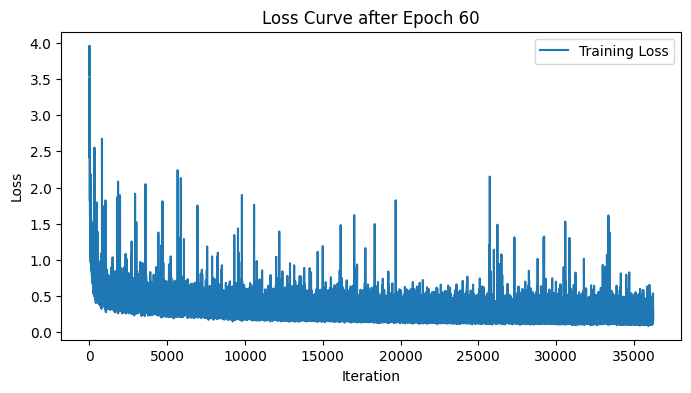

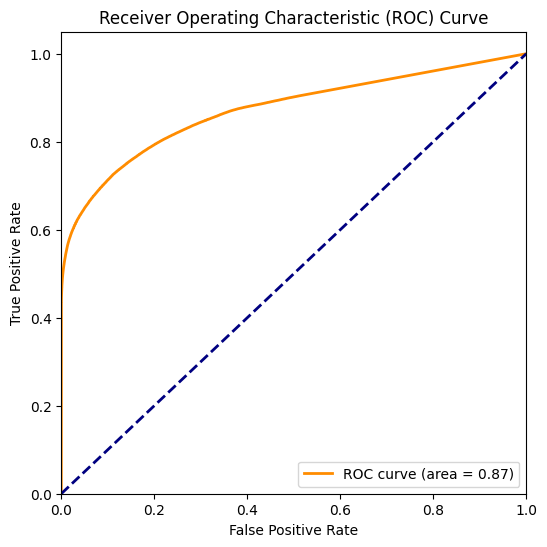

In [16]:
from sklearn.metrics import roc_curve, auc

import torch.optim as optim
import matplotlib.pyplot as plt

if run_mode == run_mode.TRAIN:
    params = [p for p in malaria_training_model.parameters() if p.requires_grad]
    optimizer = optim.SGD(params, lr=bo_learning_rate, momentum=bo_momentum, weight_decay=bo_weight_decay)

    losses_history = []

    # Store true labels and predicted scores for ROC
    all_true_labels = []
    all_pred_scores = []

    for epoch in range(num_epochs):
        epoch_losses = malaria_training_model.train(optimizer)

        # Collect predictions and true labels for ROC
        malaria_training_model.set_to_evaluation_mode()
        with torch.no_grad():
            for images, targets in train_oversampled_data_loader:
                images = [img.to(device) for img in images]
                outputs = malaria_training_model.predict(images, score_threshold=0.0)

                for target, output in zip(targets, outputs):
                    # For each class (except background), collect scores and true labels
                    for class_idx in range(1, num_classes):
                        # True: 1 if class present in target, else 0
                        true = (target['labels'].cpu().numpy() == class_idx).astype(int)
                        # Predicted: max score for this class among predictions
                        if 'scores' in output and len(output['scores']) > 0:
                            pred = output['scores'][output['labels'] == class_idx]
                            if len(pred) > 0:
                                score = pred.max()
                            else:
                                score = 0.0
                        else:
                            score = 0.0
                        all_true_labels.append(true.max() if len(true) > 0 else 0)
                        all_pred_scores.append(score)

        precision, recall, f1, accuracy = malaria_training_model.evaluate()
        print(f'Epoch {epoch+1}/{num_epochs},   Precision: {precision:.3f},     Recall: {recall:.3f}, F1: {f1:.3f},     Accuracy: {accuracy:.3f},   Loss: {np.mean(epoch_losses):.4f}')

        losses_history.extend(epoch_losses)
        malaria_training_model.save_state_dict(model_folder/f'model_epoch_{epoch+1}.pth')
        

    plt.figure(figsize=(8,4))
    plt.plot(losses_history, label='Training Loss')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title(f'Loss Curve after Epoch {epoch+1}')
    plt.legend()
    plt.show()

    # Plot ROC curve for all classes (one-vs-rest)
    fpr, tpr, _ = roc_curve(all_true_labels, all_pred_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

### Find a Best Performing Model from the Saved Dictionaries

In [17]:
import torch, numpy as np, random
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Evaluate the saved model
malaria_test_model = MalariaModel(
    dataloader=test_data_loader,
    num_classes=num_classes,  # +1 for background 
    # Use the same class weights as training, but add a weight for background
    class_weights= class_weights_tensor,
    device=device
)

#Track F1 Score for balance of precision/recall
best_f1_score = 0
best_epoch = 0

for epoch in range(num_epochs):
    malaria_test_model.load_from_checkpoint(model_folder/f'model_epoch_{epoch+1}.pth')
    precision, recall, f1, accuracy = malaria_test_model.evaluate()
    
    print(f'Epoch {epoch+1}/{num_epochs},   Precision: {precision:.3f},     Recall: {recall:.3f},       F1: {f1:.3f},     Accuracy: {accuracy:.3f}')
    if f1 > best_f1_score:
        best_f1_score = f1
        best_epoch = epoch + 1

print(f'Best F1: {best_f1_score:.3f} at epoch {best_epoch}')


Using Faster R-CNN with ResNet-50 FPN V2.
Using Focal Loss with class weights
Epoch 1/60,   Precision: 0.870,     Recall: 0.859,       F1: 0.865,     Accuracy: 0.761
Epoch 2/60,   Precision: 0.854,     Recall: 0.873,       F1: 0.863,     Accuracy: 0.760
Epoch 3/60,   Precision: 0.842,     Recall: 0.903,       F1: 0.871,     Accuracy: 0.772
Epoch 4/60,   Precision: 0.858,     Recall: 0.911,       F1: 0.884,     Accuracy: 0.792
Epoch 5/60,   Precision: 0.858,     Recall: 0.911,       F1: 0.884,     Accuracy: 0.792
Epoch 6/60,   Precision: 0.852,     Recall: 0.915,       F1: 0.882,     Accuracy: 0.790
Epoch 7/60,   Precision: 0.863,     Recall: 0.911,       F1: 0.886,     Accuracy: 0.796
Epoch 8/60,   Precision: 0.874,     Recall: 0.909,       F1: 0.891,     Accuracy: 0.804
Epoch 9/60,   Precision: 0.864,     Recall: 0.919,       F1: 0.891,     Accuracy: 0.803
Epoch 10/60,   Precision: 0.857,     Recall: 0.917,       F1: 0.886,     Accuracy: 0.796
Epoch 11/60,   Precision: 0.859,     Reca

### Evaluate a Saved Model with Test Dataset

In [18]:
import torch, numpy as np, random
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

model_file = model_folder / f'model_epoch_{best_epoch}.pth'
print(f'Loading best model from {model_file}')
# Load the best model for final evaluation

malaria_test_model.load_from_checkpoint(model_file)

Loading best model from faster_rcnn_resnet50_fpn_v2_weighted_focal_loss\model_epoch_30.pth


In [19]:
# Evaluate the model on the test dataset
precision, recall, f1, accuracy = malaria_test_model.evaluate()
print(f'Precision: {precision:.3f},     Recall: {recall:.3f},   F1: {f1:.3f},   Accuracy: {accuracy:.3f}')

Precision: 0.885,     Recall: 0.931,   F1: 0.908,   Accuracy: 0.831


### Visualize Bounding Boxes and Predictions

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision.transforms.functional as F
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from torchvision.transforms import ToPILImage

def plot_boxes(img, boxes, labels=None, color='r', title=None):
    # Assign a color to each class id
    class_ids = sorted(set(CATEGORY_MAP.values()))
    cmap = plt.get_cmap('tab10', len(class_ids))
    class_to_color = {cid: cmap(i) for i, cid in enumerate(class_ids)}

    # Reverse CATEGORY_MAP for legend
    id_to_class = {v: k for k, v in CATEGORY_MAP.items()}

    fig, ax = plt.subplots(1)
    ax.imshow(img.to(device).cpu().permute(1, 2, 0).numpy())
    handles = {}
    for i, box in enumerate(boxes):
        if labels is not None:
            class_id = int(labels[i])
            box_color = class_to_color.get(class_id, color)
            class_name = id_to_class.get(class_id, str(class_id))
        else:
            box_color = color
            class_name = None
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=2, edgecolor=box_color, facecolor='none')
        ax.add_patch(rect)
        if labels is not None and class_name not in handles:
            handles[class_name] = rect
        # Optionally, show class name on box
        #if labels is not None:
            #ax.text(xmin, ymin, class_name, color='w', fontsize=8, bbox=dict(facecolor=box_color, alpha=0.5, edgecolor='none', pad=0))
    if title:
        plt.title(title)
    if handles:
        # Place the legend outside the image
        ax.legend(handles.values(), handles.keys(), loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=10)
    plt.axis('off')
    plt.show()

### Visualize Ground Truth & Predictions of Training Dataset

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9776906].


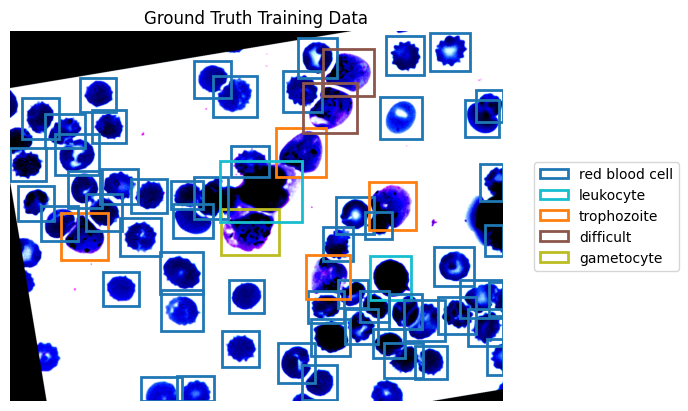

Model set to evaluation mode.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9776906].


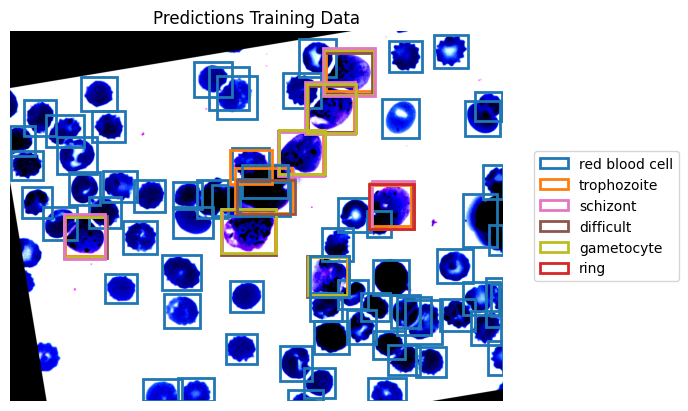

(array([0.9989894 , 0.99896693, 0.99877757, 0.99874854, 0.9987104 ,
        0.9986614 , 0.9985208 , 0.9984394 , 0.9982009 , 0.99817634,
        0.99816966, 0.99814296, 0.9979717 , 0.9979638 , 0.9978829 ,
        0.99785525, 0.99784577, 0.9974285 , 0.99734807, 0.9973322 ,
        0.99732083, 0.9972441 , 0.9972234 , 0.99694026, 0.9968407 ,
        0.9966401 , 0.99649906, 0.9964103 , 0.99622667, 0.99610883,
        0.9956626 , 0.9949693 , 0.9948678 , 0.9940528 , 0.99375457,
        0.99222577, 0.99165714, 0.99137396, 0.9911015 , 0.9907749 ,
        0.99073786, 0.98786396, 0.98784816, 0.98661554, 0.98316807,
        0.9797323 , 0.9743075 , 0.973082  , 0.97177   , 0.9711311 ,
        0.95702463, 0.9443237 , 0.90079266, 0.864639  , 0.70817083,
        0.70758355, 0.70012707, 0.6620464 , 0.64522177, 0.58726513,
        0.58583957, 0.58459115, 0.56278   , 0.546628  , 0.5079117 ,
        0.48123267, 0.46911404, 0.41941282, 0.31765234, 0.29564297,
        0.2856988 , 0.2602518 , 0.25703314, 0.24

In [21]:
# Visualize ground truth 1101, 706, 295, 859, 960, 142, 875, 960, 683, 690
#[3.537180331737787, 1.7466330368058351, 3.5824992875613857, 1.6442612961828798, 4.041775153089522, 1.2420382154541005, 2.913168856020971, 4.041775153089522, 2.2682727718996953, 1.411764703268581]
train_image, target = train_oversampled_dataset[960]
plot_boxes(train_image, target['boxes'], target['labels'], color='g', title='Ground Truth Training Data')

# Visualize predictions (after training)   
malaria_test_model.set_to_evaluation_mode()
with torch.no_grad():
    train_imgage_tensor = train_image.to(device)    
    pred = malaria_test_model.predict(train_imgage_tensor.unsqueeze(0), score_threshold=0.0)[0]

plot_boxes(train_image, pred['boxes'], pred['labels'], color='r', title='Predictions Training Data')
pred['scores'], pred['labels']

### Visualize Ground Truth & Predictions of Test Dataset

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6505601..1.0016558].


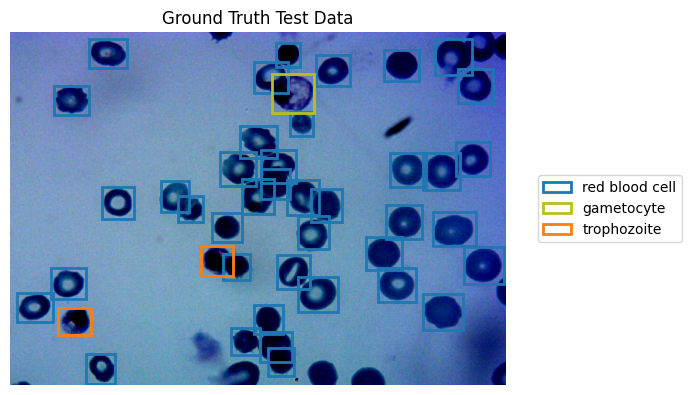

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6505601..1.0016558].


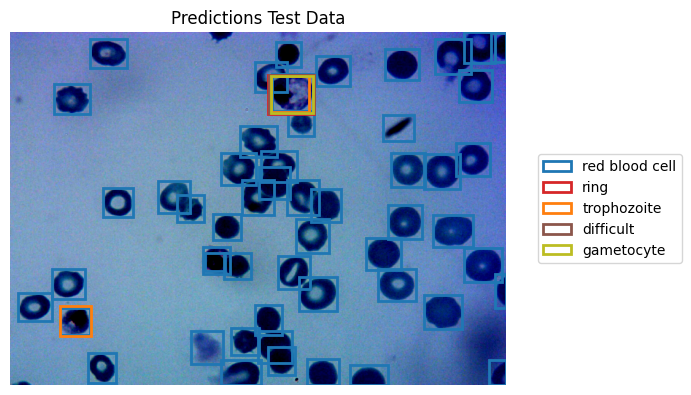

(array([0.99846447, 0.9980076 , 0.99791247, 0.9978569 , 0.9977055 ,
        0.997701  , 0.9976526 , 0.99749064, 0.99723804, 0.99719536,
        0.99668664, 0.9966577 , 0.99654335, 0.9965144 , 0.9963642 ,
        0.9963475 , 0.9963148 , 0.9954816 , 0.99541867, 0.99540824,
        0.99424994, 0.99381423, 0.99293923, 0.9929276 , 0.99281764,
        0.99258035, 0.99199355, 0.99190444, 0.9916351 , 0.9890343 ,
        0.9852443 , 0.98294383, 0.9801665 , 0.969057  , 0.95897466,
        0.9370539 , 0.93423706, 0.9330223 , 0.8492112 , 0.8002013 ,
        0.75015455, 0.73972845, 0.72164166, 0.7145117 , 0.5755712 ,
        0.5092773 , 0.46287072, 0.45705277, 0.41219878, 0.3084568 ,
        0.22253285, 0.1909451 , 0.1471733 , 0.06815121, 0.06770303,
        0.06566265, 0.06521117, 0.05534039], dtype=float32),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 3, 1, 2, 1, 4, 6, 2,

In [22]:
# Visualize ground truth
test_image, target = test_dataset[12]
plot_boxes(test_image, target['boxes'], target['labels'], color='g', title='Ground Truth Test Data')

# Visualize predictions (after training)
with torch.no_grad():
    test_image_tensor = test_image.to(device)    
    pred = malaria_test_model.predict(test_image_tensor.unsqueeze(0), score_threshold=0.0)[0]

plot_boxes(test_image, pred['boxes'], pred['labels'], color='r', title='Predictions Test Data')
pred['scores'], pred['labels']

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(malaria_model, dataloader, class_names, data=""):
    malaria_model.set_to_evaluation_mode()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for images, targets in dataloader:
            outputs = malaria_model.predict(images, score_threshold=0.0)
            for target, output in zip(targets, outputs):
                pred_labels = output['labels']
                true_labels = target['labels']
                # For confusion matrix, just use all predicted and true labels (flattened)
                y_true.extend(true_labels.tolist())
                y_pred.extend(pred_labels.tolist())
    # Pad y_pred or y_true to have the same length for confusion_matrix
    min_len = min(len(y_true), len(y_pred))
    if len(y_true) != len(y_pred):
        print(f"Warning: y_true and y_pred have different lengths ({len(y_true)} vs {len(y_pred)}). Truncating to {min_len}.")
        y_true = y_true[:min_len]
        y_pred = y_pred[:min_len]
    cm = confusion_matrix(y_true, y_pred, labels=list(range(1, len(class_names)+1)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names[0:])
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    plt.title(f'Confusion Matrix {data} Data')
    plt.show()

Model set to evaluation mode.


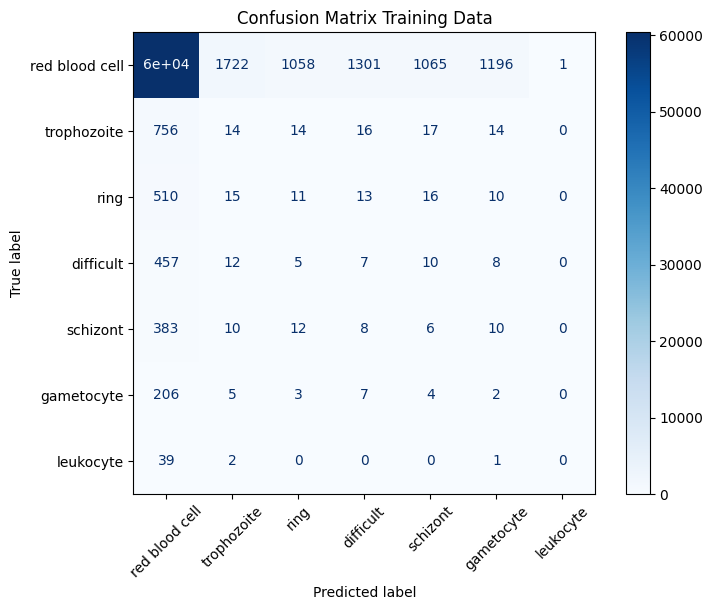

In [24]:
class_names = list(CATEGORY_MAP.keys())
plot_confusion_matrix(malaria_test_model, train_oversampled_data_loader, class_names, data="Training")

Model set to evaluation mode.


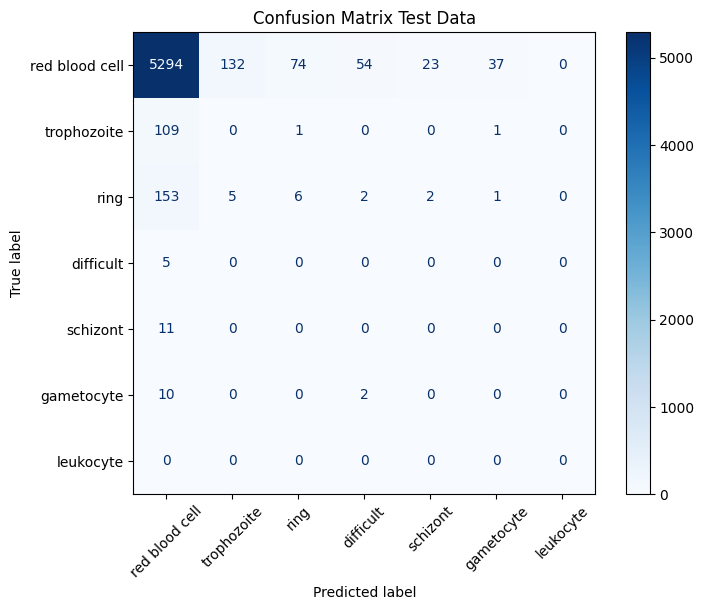

In [25]:
plot_confusion_matrix(malaria_test_model, test_data_loader, class_names, data="Test")

In [26]:
import json

# Create CATEGORY_MAP from a JSON annotation file

def create_category_map_from_json(json_file):
    with open(json_file, 'r') as f:
        data = json.load(f)
    categories = set()
    for item in data:
        for obj in item.get('objects', []):
            categories.add(obj['category'])
    categories = sorted(categories)
    category_map = {cat: idx + 1 for idx, cat in enumerate(categories)}
    return category_map


category_map = create_category_map_from_json('training.json')
print(category_map)

{'difficult': 1, 'gametocyte': 2, 'leukocyte': 3, 'red blood cell': 4, 'ring': 5, 'schizont': 6, 'trophozoite': 7}


In [27]:
category_map = create_category_map_from_json('test.json')
print(category_map)

{'difficult': 1, 'gametocyte': 2, 'red blood cell': 3, 'ring': 4, 'schizont': 5, 'trophozoite': 6}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6505601..1.0016558].


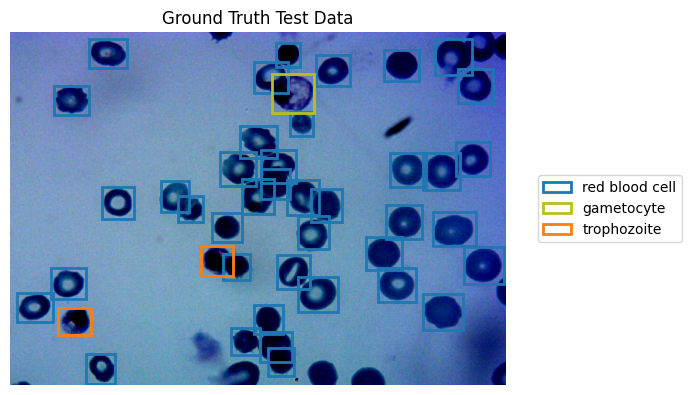

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6505601..1.0016558].


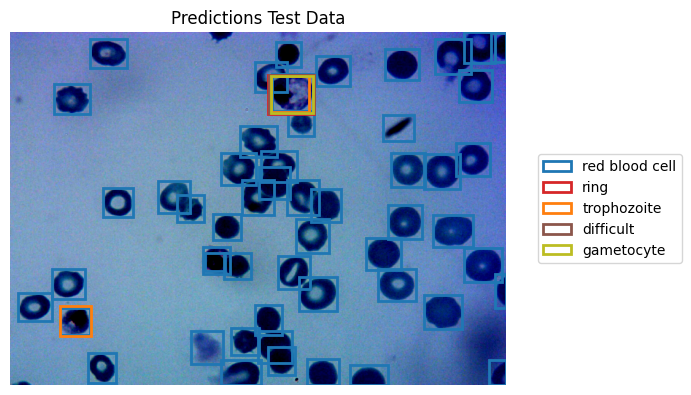

In [28]:
import pandas as pd
import numpy as np

# Visualize ground truth
test_image, target = test_dataset[12]
plot_boxes(test_image, target['boxes'], target['labels'], color='g', title='Ground Truth Test Data')

# Visualize predictions (after training)
with torch.no_grad():
    test_image_tensor = test_image.to(device)    
    pred = malaria_test_model.predict(test_image_tensor.unsqueeze(0), score_threshold=0.0)[0]

plot_boxes(test_image, pred['boxes'], pred['labels'], color='r', title='Predictions Test Data')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6505601..1.0016558].


Class thresholds: {'red blood cell': 0.6999999998770929, 'trophozoite': 0.023642679014313737, 'ring': 0.03077128606683803, 'difficult': 0.010614535090734853, 'schizont': 0.011351977199616677, 'gametocyte': 0.011474884217763647, 'leukocyte': 0.01}
                                                  box     score  label
0   [1655.95751953125, 714.3126831054688, 1814.523...  0.998464      1
1   [1479.7677001953125, 678.0009155273438, 1614.8...  0.998008      1
2   [827.4248657226562, 473.3934020996094, 962.526...  0.997912      1
3   [976.4339599609375, 527.54833984375, 1098.4627...  0.997857      1
4   [1440.5804443359375, 926.3134765625, 1589.0916...  0.997706      1
5   [1048.7696533203125, 876.0132446289062, 1173.5...  0.997701      1
6   [1395.161865234375, 805.0057983398438, 1533.82...  0.997653      1
7   [1133.48876953125, 960.3182983398438, 1281.638...  0.997491      1
8   [1620.235107421875, 476.53118896484375, 1762.4...  0.997238      1
9   [172.8982391357422, 204.40618896484375,

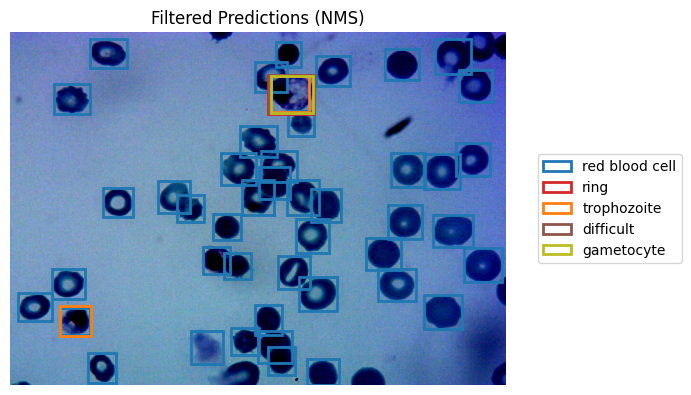

In [29]:
 # Remove overlapping boxes: keep only the box with the higher score for each overlap

def iou(box1, box2):
    # box: [xmin, ymin, xmax, ymax]
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    box1Area = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    box2Area = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])
    unionArea = box1Area + box2Area - interArea + 1e-6
    return interArea / unionArea if unionArea > 0 else 0

def non_max_suppression(data, iou_threshold=0.5):
    if not data:
        return []
    # Sort by score descending
    data = sorted(data, key=lambda x: x['score'], reverse=True)
    keep = []
    while data:
        best = data.pop(0)
        keep.append(best)
        data = [
            d for d in data
            if iou(best['box'], d['box']) < iou_threshold
        ]
    return keep

# Convert prediction results to a DataFrame for better visualization
boxes = pred['boxes']
scores = pred['scores']
labels = pred['labels']

# Prepare data for the table
data = []
for i in range(len(boxes)):
    box = boxes[i]
    score = scores[i]
    label = labels[i]
    data.append({
        'box': [float(b) for b in box],
        'score': float(score),
        'label': int(label)
    })
   

#data = non_max_suppression(data, iou_threshold=0.95)
# Class distribution (counts)
class_counts, _ = malaria_data_loader.get_class_distribution(test_dataset)
# Map class index to class name (CATEGORY_MAP is already defined above)
idx_to_class = {v: k for k, v in CATEGORY_MAP.items()}
# Compute thresholds: higher for frequent classes, lower for rare classes
max_count = max(class_counts.values())
min_thresh = 0.01
max_thresh = 0.7
# Inverse proportional threshold: rare class -> low threshold, common class -> high threshold
class_thresholds = {}
for class_name, count in class_counts.items():
    # Normalize: 0 for rarest, 1 for most common
    norm = (count - min(class_counts.values())) / (max_count - min(class_counts.values()) + 1e-6)
    # Invert: rarest -> 1, most common -> 0
    #inv_norm = 1 - norm
    # Scale to [min_thresh, max_thresh]
    thresh = min_thresh + norm * (max_thresh - min_thresh)
    class_thresholds[class_name] = thresh

print("Class thresholds:", class_thresholds)

# Filter data by per-class threshold
filtered_data = []
for row in data:
    class_name = idx_to_class.get(row['label'], None)
    if class_name is not None:
        if row['score'] >= class_thresholds[class_name]:
            filtered_data.append(row)
    data = filtered_data
df = pd.DataFrame(data)
print(df)

# Plot filtered boxes on the image
filtered_boxes = np.array([row['box'] for row in data])
filtered_labels = np.array([row['label'] for row in data])
plot_boxes(test_image, filtered_boxes, filtered_labels, color='b', title='Filtered Predictions (NMS)')